**Week 2**

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from mortgage_rate_enrichment import add_mortgage_rates

In [8]:
listed_data = pd.read_csv('listed.csv')

/var/folders/mf/9m6y4nlx41z0kjyljz4sn3tc0000gn/T/ipykernel_24380/4097304770.py:1: DtypeWarning: Columns (0: ListAgentEmail, 1: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  listed_data = pd.read_csv('listed.csv')


Row count before Residential Filter (includes ALL PropertyType's): 853331 

Row count AFTER Residential filter: 540341


In [9]:
listed_data.shape

(540341, 84)

**Missing Value Analysis**: Identify which columns have a high percentage of missing values

In [10]:
missing_counts = listed_data.isna().sum()

missing_pct = (missing_counts / len(listed_data)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
})

missing_summary["90pct_missing"] = missing_summary["missing_pct"] > 90

missing_summary = missing_summary.sort_values(by="missing_pct", ascending=False)

missing_summary.head(10)

,missing_count,missing_pct,90pct_missing
TaxAnnualAmount,540341,100.000000,True
FireplacesTotal,540341,100.000000,True
ElementarySchoolDistrict,540341,100.000000,True
BusinessType,540341,100.000000,True
TaxYear,540341,100.000000,True
CoveredSpaces,540341,100.000000,True
MiddleOrJuniorSchoolDistrict,540341,100.000000,True
AboveGradeFinishedArea,540341,100.000000,True
BelowGradeFinishedArea,537318,99.440538,True
CoBuyerAgentFirstName,526175,97.378322,True


**Numeric Distribution Review**: What are the distributions of key numeric fields? 

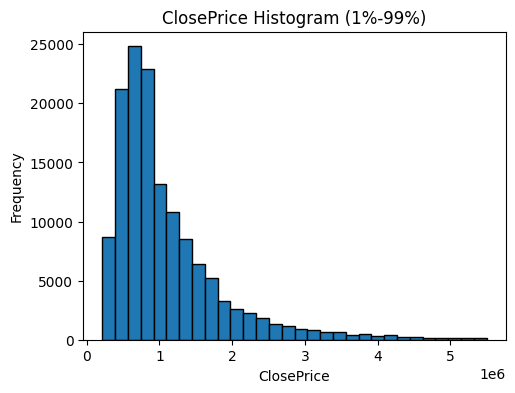

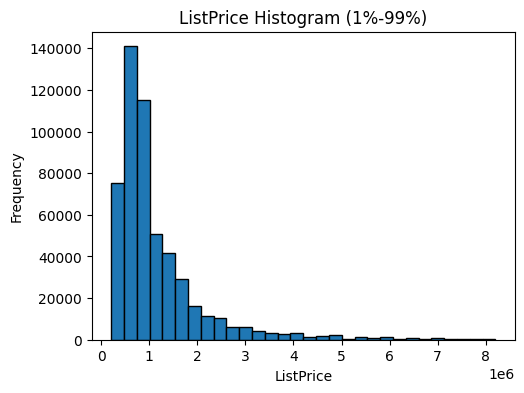

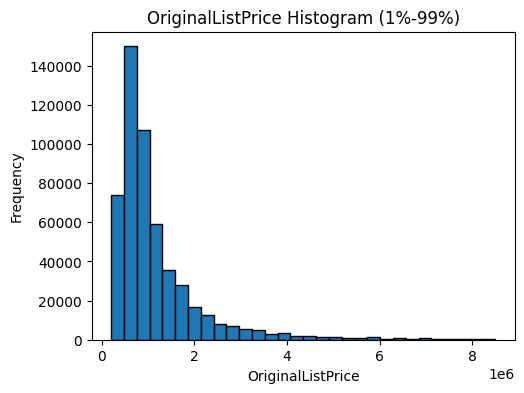

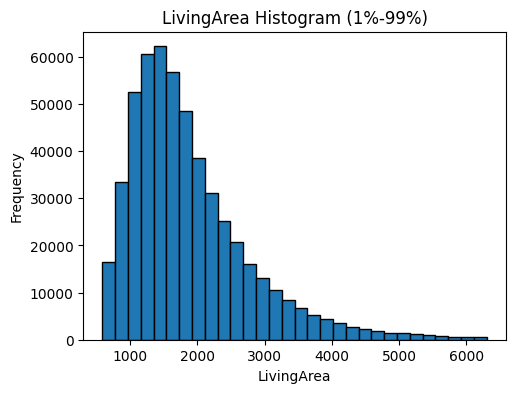

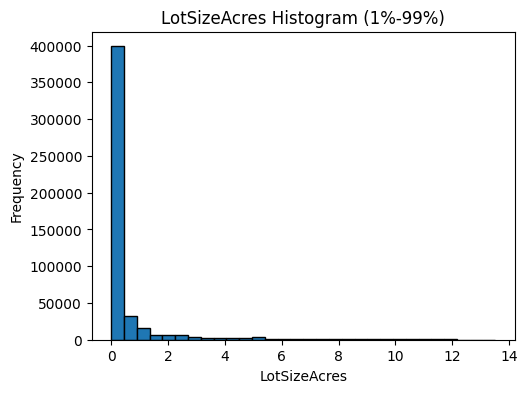

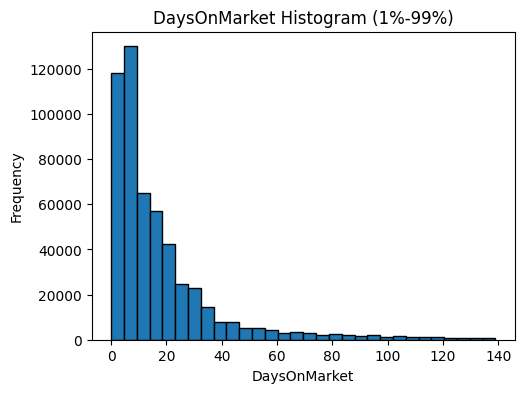

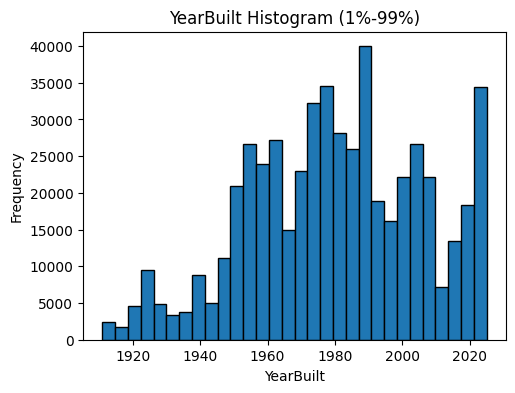

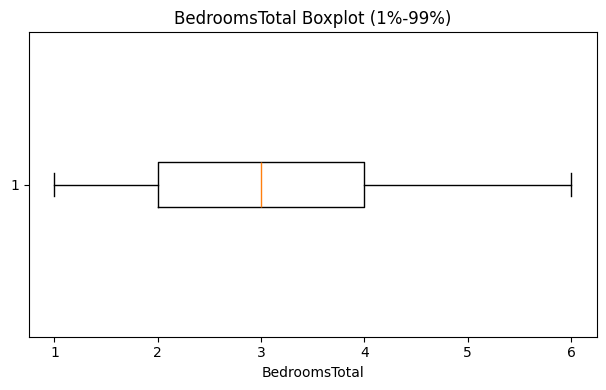

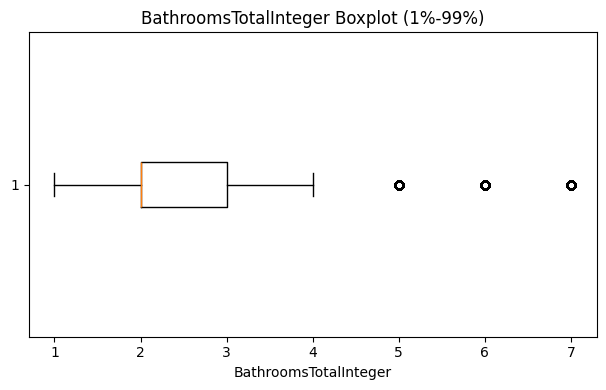

In [12]:
# HISTOGRAM PLOTTING 
cols_hist = [
    "ClosePrice", "ListPrice", "OriginalListPrice",
    "LivingArea", "LotSizeAcres",
    "DaysOnMarket", "YearBuilt"
]

for col in cols_hist:
    data = listed_data[col]

    # Missing values handling
    missing_count = data.isna().sum()

    # Drop NA values for visualization purposes
    x = data.dropna()

    # Handle extreme outliers by trimming data to range from 1st to 99th percentile
    lower = x.quantile(0.01)
    upper = x.quantile(0.99)

    trimmed = x[(x >= lower) & (x <= upper)]

    outlier_count = len(x) - len(trimmed)

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.hist(trimmed, bins=30, edgecolor="black")
    plt.title(f"{col} Histogram (1%-99%)")
    plt.xlabel(col)
    plt.ylabel("Frequency")

# BOXPLOT PLOTTING
cols_box = ["BedroomsTotal", "BathroomsTotalInteger"]

for col in cols_box:
    data = listed_data[col]

    # Missing values handling
    missing_count = data.isna().sum()

    # Drop NA values for visualization purposes
    x = data.dropna()

    # Handle extreme outliers by trimming data to range from 1st to 99th percentile
    lower = x.quantile(0.01)
    upper = x.quantile(0.99)

    trimmed = x[(x >= lower) & (x <= upper)]

    outlier_count = len(x) - len(trimmed)

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,2)
    plt.boxplot(trimmed, vert=False)
    plt.title(f"{col} Boxplot (1%-99%)")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

**Percentile Statistics**

In [14]:
column_percentile = []
outlier_dict = {}

cols = ["ClosePrice", "ListPrice", 
    "OriginalListPrice",
    "LivingArea", "LotSizeAcres",
    "DaysOnMarket", "YearBuilt", 
    "BedroomsTotal", "BathroomsTotalInteger"]

for col in cols:
    data = listed_data[col].dropna()

    percentiles = data.quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

    Q1 = percentiles.loc[0.25]
    Q3 = percentiles.loc[0.75]
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data < lower_bound) | (data > upper_bound)]
    outlier_dict[col] = outliers

    percentages = {
        "column": col,
        "1%": percentiles.loc[0.01],
        "5%": percentiles.loc[0.05],
        "25%": percentiles.loc[0.25],
        "50%": percentiles.loc[0.50],
        "75%": percentiles.loc[0.75],
        "95%": percentiles.loc[0.95],
        "99%": percentiles.loc[0.99],
        "outlier_count": len(outliers)
    }

    column_percentile.append(percentages)
    
column_distribution = pd.DataFrame(column_percentile)
column_distribution.head()

,column,1%,5%,25%,50%,75%,95%,99%,outlier_count
0,ClosePrice,215000.0,354000.0000,600000.00,851000.00,1.350000e+06,2900000.00,5.500000e+06,10252
1,ListPrice,210000.0,345000.0000,580000.00,845000.00,1.375000e+06,3450000.00,8.200000e+06,45585
2,OriginalListPrice,200000.0,347000.0000,585000.00,849000.00,1.389000e+06,3495000.00,8.500000e+06,45428
3,LivingArea,588.0,816.0000,1247.00,1669.00,2.300000e+03,3868.00,6.302120e+03,26737
4,LotSizeAcres,0.0,0.0288,0.12,0.17,3.138000e-01,3.57,1.352010e+01,79447


Median and Average Listed Prices 

In [15]:
median_listed = listed_data["ListPrice"].median()
mean_listed = listed_data["ListPrice"].mean()

print("Median List Price:", median_listed)
print("Average Close Price:", mean_listed)

Median List Price: 845000.0
Average Close Price: 1314105.9624618157


Counties with highest median listed price 

In [17]:
county_prices = (
    listed_data.groupby("CountyOrParish")["ListPrice"]
    .median()
    .sort_values(ascending=False)
)

print("\nTop Counties by Median List Price:")
print(county_prices.head(10))


Top Counties by Median List Price:
CountyOrParish
San Mateo        1648950.0
Santa Clara      1499000.0
Marin            1295000.0
Santa Cruz       1250000.0
Orange           1200000.0
San Francisco    1098000.0
Alameda           998000.0
Monterey          990000.0
Los Angeles       950000.0
San Diego         910000.0
Name: ListPrice, dtype: float64


**Summary Statistics**

In [19]:
summary_list = []
for col in cols: 
    data = listed_data[col].dropna()
    summary = {
        "column": col,
        "count": len(data),
        "mean": data.mean(),
        "median": data.median(),
        "std": data.std(),
        "min": data.min(),
        "max": data.max(),
    }
    
    summary_list.append(summary)
    
summary_df = pd.DataFrame(summary_list)
summary_df.head(5)

,column,count,mean,median,std,min,max
0,ClosePrice,142967,1.201249e+06,851000.00,4.329322e+06,525.0,8.200000e+08
1,ListPrice,540341,1.314106e+06,845000.00,2.348922e+06,100.0,1.950000e+08
2,OriginalListPrice,539574,1.398075e+06,849000.00,7.356544e+06,0.0,1.390000e+09
3,LivingArea,539789,1.980076e+03,1669.00,2.337920e+04,0.0,1.702132e+07
4,LotSizeAcres,495766,6.525178e+01,0.17,1.213560e+04,0.0,4.187292e+06


**Week 3**

**Mortgage Rate Enrichment**

Add Mortgage Rates from Fred into the dataset

In [21]:
# Fetch mortgage data
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"

mortgage = pd.read_csv(url)

mortgage.columns = ["date", "rate_30yr_fixed"]

mortgage["date"] = pd.to_datetime(mortgage["date"], errors="coerce")

mortgage.head()

,date,rate_30yr_fixed
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


In [22]:
# Convert weekly data to monthly averages
mortgage["year_month"] = mortgage["date"].dt.to_period("M")

mortgage_monthly = (
    mortgage.groupby("year_month")["rate_30yr_fixed"]
    .mean()
    .reset_index()
)

mortgage_monthly.head()

,year_month,rate_30yr_fixed
0,1971-04,7.3100
1,1971-05,7.4250
2,1971-06,7.5300
3,1971-07,7.6040
4,1971-08,7.6975


In [36]:
# Create matching monthly keys
listed_data["ListingContractDate"] = pd.to_datetime(
    listed_data["ListingContractDate"], errors="coerce"
)

listed_data["year_month"] = (
    listed_data["ListingContractDate"].dt.to_period("M")
)

# Merge with dataset
listed_with_rates = listed_data.merge(
    mortgage_monthly,
    on="year_month",
    how="left"
)

# Preview merged dataset
listed_with_rates[
    ["ListingContractDate", "year_month", "ListPrice", "rate_30yr_fixed"]
].head()

,ListingContractDate,year_month,ListPrice,rate_30yr_fixed
0,2026-02-16,2026-02,999000.0,6.0475
1,2026-02-26,2026-02,2050000.0,6.0475
2,2026-02-09,2026-02,3105000.0,6.0475
3,2026-02-24,2026-02,900000.0,6.0475
4,2026-02-26,2026-02,2295000.0,6.0475
